# Michael Vazquez<br>Econ 586, Assignment 3<br>Link to code:

## Imports and global settings

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp

from statsmodels.tsa.stattools import acf

import requests

import warnings

import os

from IPython.display import display, Math, Image

warnings.filterwarnings('ignore')

# Want the Greek letters to display nicely in plots.
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,
    'mathtext.fontset': 'cm',
})



# Problem 1.0 - Secular Stagnation in the Solow Model

Suppose we have a Cobb-Douglas production in intensive form $f(k) = k(t)^\alpha$, where $k = K/(AL)$ is capital per effective worker. Assume zero population growth $n=0$, and
the growth of technological progress is $(\dot{A}(t)/A(t)) = \gamma$.


## Question 1.1 - Steady state $k^*$, given $\gamma > 0, \alpha, s, \delta \in (0, 1).$

**References: Chapter 3, pages 60, 61**

With the intensive form $f(k) = k(t)^\alpha$ and $n = 0$, the Solow equation for capital per effective worker is:

$$\dot{k} = s f(k) - (\gamma + \delta)\,k = s\,k^\alpha - (\gamma+\delta)\,k$$

The term $(\gamma+\delta)k$ is breakeven investment, which in balanced growth must be equal to savings per effective worker.

$\implies$ Let $\dot{k}=0$:

$s\,(k^*)^\alpha = (\gamma+\delta)\,k^*$

Solving for $k^*$, we get:

$\boxed{k^* = \left(\frac{s}{\delta+\gamma}\right)^{\!1/(1-\alpha)}}$

Looking at page 61 of Chapter 3, we can confirm that the boxed result of $k^*$ is correct here. The last formula on the page is:

$k^*$ = $\left(\frac{sA}{n+\delta+\gamma}\right)^{\!1/(1-\alpha)}$

This formula uses $f(k) = Ak^\alpha$, resulting in $sA$ in the numerator. However, in this question we are using the intensive form $f(k) = k(t)^\alpha$, essentially setting $A = 1$. By this question's assumptions, $n = 0$. Taking the page 61 formula, plugging in $A = 1$ and $n = 0$ confirms our findings of $k^*$ in the above boxed result.

In [128]:
# Use SymPy and setup k* here. Will use this in Question 1.2.
s_sym, delta_sym, gamma_sym, alpha_sym = sp.symbols(
    r's \delta \gamma \alpha', positive=True)

k_star_sym = (s_sym / (gamma_sym + delta_sym)) ** (1 / (1 - alpha_sym))
display(Math(r"k^* =" + sp.latex(k_star_sym)))


<IPython.core.display.Math object>

## Question 1.2 - New steady state $k^{**}$ when $\gamma$ falls permanently to $0$.

**References: Chapter 3, pages 60, 61**

Plugging $\gamma = 0$ into the boxed result from Question 1.1, and letting $k^{**}$ denote the new steady state:

$\boxed{k^{**} = \left(\frac{s}{\delta}\right)^{\!1/(1-\alpha)}}$

It is immediately clear that $k^{**}$ is larger than $k^*$, as $k^{**}$ has a smaller denominator.

$\delta \lt \delta+\gamma \implies k^* = \frac{s}{\delta+\gamma} \lt k^{**} = \frac{s}{\delta} \implies k^* \lt k^{**}$


**Intuition:**

With $\gamma > 0$, the breakeven investment is $(\gamma+\delta)k$.
When $\gamma \to 0$, the breakeven investment falls to $\delta k$, so the same saving rate $s$ sustains a higher capital to labor ratio at the steady state.


In [129]:
# Let's test this new steady state k** using SymPy.
display(Math("k^* =" + sp.latex(k_star_sym)))

k_star_new_sym = k_star_sym.subs(gamma_sym, 0)
display(Math("k^{**} =" + sp.latex(k_star_new_sym)))

# All caps, don't want to confuse these with the SymPy symbols.
ALPHA = 1/4
S = 0.35
DELTA = 0.04
GAMMA = 0.02
print(f'Plug in some values to test k* vs k**.\nalpha={ALPHA:.3f},\ns={S},\ndelta={DELTA},\ngamma={GAMMA}:')

k_old = (S / (DELTA + GAMMA)) ** (1 / (1 - ALPHA))
# Omit the GAMMA in k**, ie GAMMA = 0 here.
k_new = (S / DELTA) ** (1 / (1 - ALPHA))
print(f'k* = {k_old:.4f}')
print(f'k** = {k_new:.4f}')
assert k_old < k_new, "k_old is supposed to be less than k_new."


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Plug in some values to test k* vs k**.
alpha=0.250,
s=0.35,
delta=0.04,
gamma=0.02:
k* = 10.5008
k** = 18.0306


## Question 1.3 - Adjustment of $k(t)$ over time.

**References: Chapter 3, pages 60, 61**

At $t=0$ the economy is at $k(0)=k^*$, strictly below $k^{**}$, as shown in Question 1.2. The new Solow equation is $\dot{k} = s k^\alpha - \delta k$.

Since $k^* < k^{**}$ we have $s\,k(0)^\alpha > \delta\,k(0)$, so $\dot{k}>0$. Capital per effective worker rises toward $k^{**}$.
The gap between $sf(k)$ and breakeven investment $\delta k$ narrows as $k$ increases, following the Solow equation.



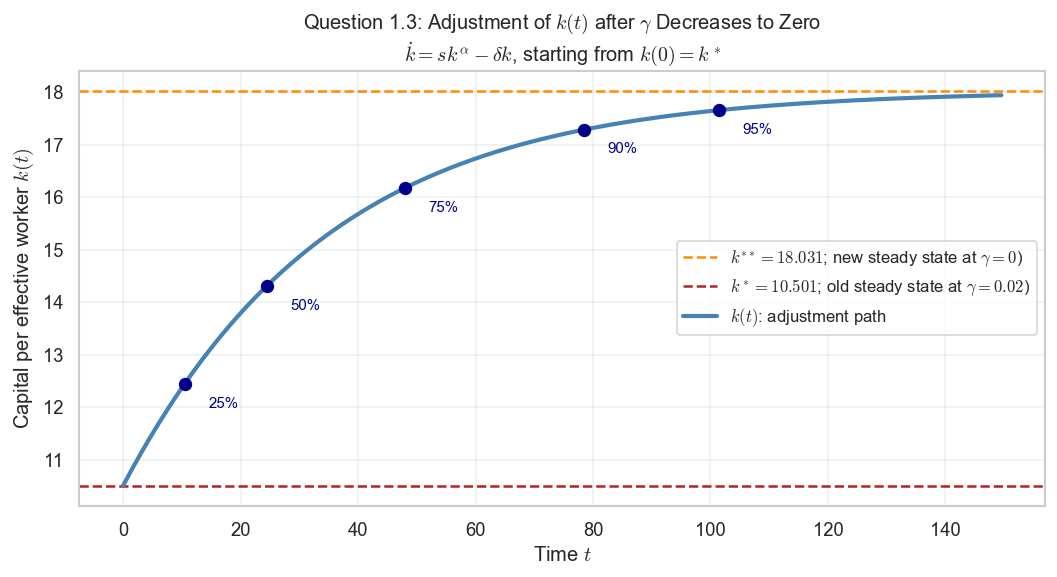

25% of gap closed at (t = 10.5, k(t) = 12.4448)
50% of gap closed at (t = 24.5, k(t) = 14.3123)
75% of gap closed at (t = 48.0, k(t) = 16.1760)
90% of gap closed at (t = 78.5, k(t) = 17.2868)
95% of gap closed at (t = 101.5, k(t) = 17.6585)


In [130]:
# Let's plot the adjustment path of k(t) from k* toward k**, using the parameter values from QUestion 1.2.

def k_ss(s, gamma, delta, alpha):
    """k* = (s/(gamma+delta))^(1/(1-alpha))"""
    return (s / (gamma + delta)) ** (1.0 / (1.0 - alpha))

# Rate of change of k(t).
def dk_dt(k, s, alpha, delta):
    """dk/dt = s*k^alpha - delta*k"""
    return s * k**alpha - delta * k

k_old = k_ss(S, DELTA, GAMMA, ALPHA)
k_new = k_ss(S, DELTA, 0.0, ALPHA)

T, DT = 300, 0.5
k_path = np.zeros(T)
k_path[0] = k_old
for t in range(1, T):
    k_path[t] = k_path[t-1] + dk_dt(k_path[t-1], S, ALPHA, DELTA) * DT
time = np.arange(T) * DT


fig, ax = plt.subplots(figsize=(9, 5))

# Plot the steady state lines.
ax.axhline(
    k_new,
    color='darkorange',
    lw=1.5,
    ls='--',
    label=fr'$k^{{**}}={k_new:.3f}$; new steady state at $\gamma=0$)'
)
ax.axhline(
    k_old,
    color='firebrick',
    lw=1.5,
    ls='--',
    label=fr'$k^*={k_old:.3f}$; old steady state at $\gamma={GAMMA}$)'
)


# Plot the adjustment path.
ax.plot(time, k_path, color='steelblue', lw=2.5, label=r'$k(t)$: adjustment path')

# (k_path - k_old) tracks how far k(t) has travels from the starting
# point k_old.
# (k_new - k_old) is the distance between k* and k**.
pct_done = ((k_path - k_old) / (k_new - k_old)) * 100
tgts = [25, 50, 75, 90, 95]
tgt_idxs = [int(np.argmax(pct_done >= tgt)) for tgt in tgts]

# Plot some points along the curve, showing the path increasing towards the new steady state k**.
for tgt, idx in zip(tgts, tgt_idxs):
    ax.plot(time[idx], k_path[idx], 'o', color='darkblue', ms=7, zorder=5)
    ax.annotate(
        f'{tgt}%',
        xy=(time[idx],
        k_path[idx]),
        xytext=(time[idx] + 4, k_path[idx] - 0.45),
        fontsize=9,
        color='darkblue'
    )

ax.set_xlabel('Time $t$')
ax.set_ylabel(r'Capital per effective worker $k(t)$')
ax.set_title(
    r'Question 1.3: Adjustment of $k(t)$ after $\gamma$ Decreases to Zero' '\n'
    r'$\dot{k}=sk^\alpha-\delta k$, starting from $k(0)=k^*$'
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

for tgt, idx in zip(tgts, tgt_idxs):
    print(f'{tgt}% of gap closed at (t = {time[idx]:.1f}, k(t) = {k_path[idx]:.4f})')



## Question 1.4 - Adjustment path of per-capita output $Y(t)/L(t)$

**References: Given hint, and Chapter 3 pages 63, 64.**


Per capita output: $Y/L = A(t)\,k(t)^\alpha$.
Proportional growth rate (PS hint):

$$g_{Y/L} = \frac{\dot{A}}{A} + \alpha\,\frac{\dot{k}}{k} = \gamma + \alpha\,\frac{\dot{k}}{k}$$

At $t=0$, $\gamma$ drops to $0$ but $k$ is still at $k^*$, so from the old steady state condition $sk^{*\,\alpha-1}=\gamma+\delta$ the new law of motion gives $\dot{k}=\gamma k^*$. Substituting into the PS hint formula:

$$g_{Y/L}(0) = 0 + \alpha\cdot\gamma = \alpha\gamma < \gamma$$

Growth then continues declining toward $0$ as $\dot{k}\to 0$. During the transition, $\dot{k}>0$ so the second term $\alpha\dot{k}/k$ in the  hint formula remains positive, sustaining positive per capita growth until $k$ reaches $k^{**}$. These findings aligns with Chapter 3 page 63, 64: "...the long run growth rate of per capita income is given by the rate of growth of technology, gamma."


## Question 1.5 - Adjustment of interest rates over time.

**References: Chapter 3, page 58**

Per page 58, "...in a market economy associated with the Solow model, the interest rate would be:

$$r(t) - \delta = f'(k(t)) - \delta$$
"

Plugging in the intensive form, as used in earlier parts of Question 1, then taking the derivative, we get:
 $r(t) = \alpha\,k(t)^{\alpha-1} - \delta$

Plugging in $k^*$ and $k^{**}$ found in Question 1.1 and Question 1.2,
 $$r^* = \alpha(\gamma+\delta)/s - \delta$$
$$r^{**} = \alpha\delta/s - \delta$$
$$\implies r^{**} - r^* = -\frac{\alpha\gamma}{s} < 0$$

Thus, the long-run interest rate **falls** by $\alpha\gamma/s$.

During the adjustment process, $k(t)$ rises from $k^*$ to $k^{**}$, as seen in the plot for Question 1.3. Since $r(t) = \alpha k(t)^{\alpha-1} - \delta$ and $\alpha-1 < 0$, $r(t)$ falls as $k(t)$ rises.


## Question 1.6 - Can the Solow model explain secular stagnation?

**References: Chapter 3, page 63**


Let's go over each question/condition in the paragraph to determine if the Solow model can explain secular stagnation, referring the findings in the above questions.

**Q, Condition 1:** Can a permanent fall in technological progress in the Solow medel be consistent with permanently lower per capita output growth and lower interest rates?<br>
**A:** Yes, we observed this in Question 1.4 when $\gamma$ fell to zero.

**Q, Condition 2:** Can it be consistent with reductions in per capita growth and interest rates in the short run, ie during the adjustment process?<br>
**A:** Yes, in Question 1.5, $r(t)$ decreases as $k$ increases.<br>

**Conclusion:** It appears the Solow model can explain secular stagnation, as a permanent fall in $\gamma$ satisfies the two above conditions. However, page 63 states "Solow accounting attributes growth to its proximate sources, but may fail to identify the ultimate causes of growth." Thus, it is possible that despite the two above conditions holding, that the Solow model may not completely explain secular stagnation.


# Problem 2 - Simulating the Stochastic Solow Model
**References: solowstochastic2026.pdf, slides 7 - 13; 15 - 19**

## Question 2.1 - Law of motion of $k_{t+1}$

Taking the formulas in the slides:

$$K_{t+1} = (1-\delta)K_t + I_t, \qquad L_{t+1} = (1+n)L_t, \qquad I_t = s Y_t$$

$$Y_t = z_t\,F(K_t,L_t), \qquad F(K,L) = K^\alpha L^{1-\alpha}$$

$$\log z_t = \rho\,\log z_{t-1} + \varepsilon_t, \quad |\rho|<1, \quad
\varepsilon_t \sim \mathrm{WN}(0,\sigma_\varepsilon^2)$$

Combine $I_t=sY_t$ with capital accumulation and divide by $L_{t+1}=(1+n)L_t$,
using $k_t=K_t/L_t$, $f(k)=k^\alpha$:

$$\boxed{k_{t+1} = g(k_t,z_t) = \frac{(1-\delta)k_t + z_t\,s\,k_t^\alpha}{1+n}}$$

This boxed result exactly matches the last formula on slide 9.


In [131]:
# Let's test the motion formula.
# THe suffix _P2, not to confuse with the constants assigned in question 1.
N_P2 = 0
ALPHA_P2 = 1/3
DELTA_P2 = 0.02
S_P2 = 0.10
RHO_P2 = 0.90
SIG_P2 = 0.01

def g_capital(k, z, s, alpha, delta, n):
    """Formula from slide 9 of solowstochastic2026.pdf.
    """
    return (((1.0 - delta) * k) + (z * s * (k**alpha))) / (1.0 + n)

# g(k_bar, 1) should equal k_bar, per slide 11.
k_bar_test = (S_P2 / DELTA_P2) ** (1.0 / (1.0 - ALPHA_P2))
g_test = g_capital(k_bar_test, 1.0, S_P2, ALPHA_P2, DELTA_P2, N_P2)
assert abs(g_test - k_bar_test) < 1e-9, "g_test and k_bar_test should have a very small difference."

## Question 2.2 -- Nonstochastic steady state $k^*$

Question 1.2 states that $\gamma$ is zero for the remaining questions. We may take the nonstochastic steady state $k^*$ that we already computed in Question 1.2:

$$\boxed{k^* = \left(\frac{s}{\delta}\right)^{\!1/(1-\alpha)}}$$


In [132]:
# Question 2.2 - nonstochastic steady state.

def nonstochastic_ss(s, delta, alpha):
    """k_star_p2 = (s/delta)^(1/(1-alpha))"""
    return (s / delta) ** (1.0 / (1.0 - alpha))

K_STAR_P2 = nonstochastic_ss(S_P2, DELTA_P2, ALPHA_P2)
print('Question 2.2 Nonstochastic steady state:')
print(f'Parameters:\nn={N_P2}\nalpha={ALPHA_P2:.4f}\ndelta={DELTA_P2}\ns={S_P2}')
print(f'k* = (s/delta)^(1/(1-alpha)) = {K_STAR_P2:.6f}')


Question 2.2 Nonstochastic steady state:
Parameters:
n=0
alpha=0.3333
delta=0.02
s=0.1
k* = (s/delta)^(1/(1-alpha)) = 11.180340


## Question 2.3 - Simulate $T=10{,}000$ periods.

$$\log z_t = \rho\,\log z_{t-1} + \varepsilon_t, \quad
\varepsilon_t\sim\mathrm{WN}(0,\sigma_\varepsilon^2)$$

Starting conditions: $z_0=1$, $k_1=k^*$.

Output per worker formula: $y_t = z_t\,k_t^\alpha$


In [133]:
# Question 2.3 stochastic simulation.

def simulate_solow_stochastic(T, k0, rho, sigma_eps, s, alpha, delta, n, seed=42):
    """Simulate the stochastic Solow model for T periods.
    Returns k_path, z_path, y_path each of length T."""

    rng = np.random.default_rng(seed)
    eps = rng.normal(0.0, sigma_eps, T)

    # log z_t = rho*log z_{t-1} + eps_t, z_0=1; slide 8
    log_z = np.zeros(T + 1)
    log_z[0] = np.log(1.0)
    for t in range(T):
        log_z[t + 1] = rho * log_z[t] + eps[t]
    z_all = np.exp(log_z)

    # Capital: k_{t+1} = g(k_t, z_t); Slide 9
    k = np.zeros(T + 1)
    k[0] = k0  # k_1 = k_bar; Slide 13
    for t in range(T):
        k[t + 1] = ((1.0 - delta) * k[t] + z_all[t] * s * k[t]**alpha) / (1.0 + n)

    k_path = k[:T]
    z_path = z_all[:T]
    # y_t = z_t*k_t^alpha; Slide 19]
    y_path = z_path * k_path**alpha
    return k_path, z_path, y_path

T_P2 = 10_000
k_sim, z_sim, y_sim = simulate_solow_stochastic(
    T=T_P2,
    k0=K_STAR_P2,
    rho=RHO_P2,
    sigma_eps=SIG_P2,
    s=S_P2,
    alpha=ALPHA_P2,
    delta=DELTA_P2,
    n=N_P2
)


# k_sim is the simulated k* steady state.
print("Simulation code ran successfully.")
# Print mean and std. Technically the question only asks for the simulation
# to be run.
print(f'Question 2.3 Simulation (T={T_P2:,}):\n')
print(f'k_star_p2 = {K_STAR_P2:.4f}')
print()
print(f'Simulated mean: {np.mean(k_sim):.4f}\nSimulated standard deviation: {np.std(k_sim):.4f}')


Simulation code ran successfully.
Question 2.3 Simulation (T=10,000):

k_star_p2 = 11.1803

Simulated mean: 11.1677
Simulated standard deviation: 0.1405


## Question 2.4 - Plot of $k_t$. Does the path stay close to $k^*$?


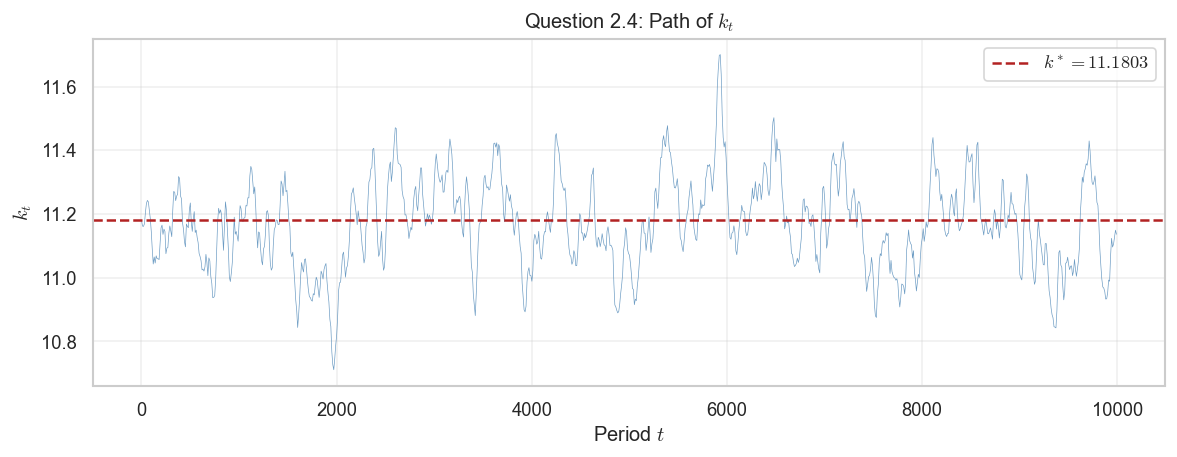

In [134]:
# Question 2.4 - plot k_t
# Follows slides 8-11 from solowstochastic.pdf.

t_idx_p2 = np.arange(1, T_P2 + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_idx_p2[::10], k_sim[::10], lw=0.4, color='steelblue', alpha=0.8)
ax.axhline(K_STAR_P2, color='firebrick', lw=1.5, ls='--',
           label=f'$k^*={K_STAR_P2:.4f}$')
ax.set_xlabel('Period $t$')
ax.set_ylabel('$k_t$')
ax.set_title('Question 2.4: Path of $k_t$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

rho_k = ALPHA_P2 * DELTA_P2 + (1.0 - DELTA_P2)


##### Yes, the simulated path of $k_t$ clearly stays close to the steady state $k^*$ over all 10,000 simulated periods.

## Question 2.5 - Output $y_t$: standard deviation and first 12 autocorrelations.

The steps for log linearized output process is given in slides 15 - 19.

$$\hat{y}_t = \hat{z}_t + \alpha\,\hat{k}_t$$

Log-linearized capital dynamics:

$$\hat{k}_{t+1} = \rho_k\,\hat{k}_t + \eta\,\hat{z}_t, \quad
\hat{z}_t = \rho\,\hat{z}_{t-1} + \varepsilon_t$$

with $\rho_k = \alpha\delta + (1-\delta)$, $\eta=\delta$.


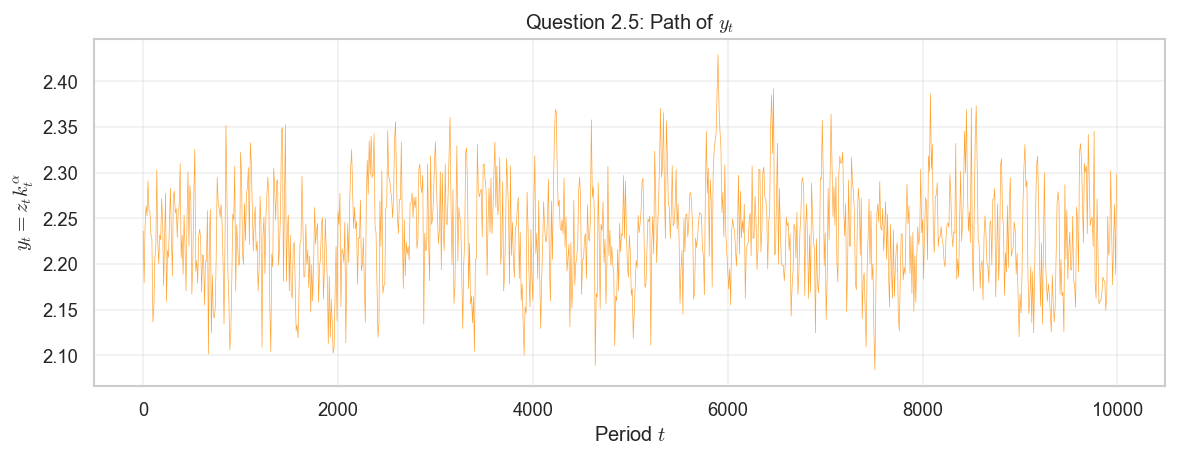

Question 2.5, y_t standard deviation: 0.0562
First 12 autocorrelations of y_t:


,Lag,Autocorrelation
0,1,0.916435
1,2,0.839611
2,3,0.770788
3,4,0.711115
4,5,0.657513
5,6,0.608853
6,7,0.567568
7,8,0.527535
8,9,0.489748
9,10,0.457480


In [135]:
# Question 2.5 - y_t path, std, and first 12 autocorrelations

def compute_acf(series, max_lag):
    """Sample autocorrelations at lags 1..max_lag.
    """
    x = series - np.mean(series)
    T = len(x)
    return np.array([
        np.corrcoef(x[lag:], x[:T - lag])[0, 1]
        for lag in range(1, max_lag + 1)
    ])

# Question only wants 12 autocorrelations.
MAX_LAG = 12
lags = np.arange(1, MAX_LAG + 1)
# Exclude the 0 lag.
acf_y = acf(y_sim, nlags=MAX_LAG, fft=True)[1:]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_idx_p2[::10], y_sim[::10], lw=0.4, color='darkorange', alpha=0.8)
ax.set_xlabel('Period $t$')
ax.set_ylabel(r'$y_t = z_t k_t^\alpha$')
ax.set_title('Question 2.5: Path of $y_t$')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Question 2.5, y_t standard deviation: {np.std(y_sim):.4f}')
print(f'First 12 autocorrelations of y_t:')

# DataFrame for question 2.5.
df_2_5 = pd.DataFrame(
    data={k: [v] for k, v in zip(lags, acf_y)}
    )\
    .T\
    .reset_index()\
    .rename(columns={'index': 'Lag', 0: 'Autocorrelation'})
display(df_2_5)
assert df_2_5['Autocorrelation'].is_monotonic_decreasing,\
    "We expect the autocorrelations here to be strictly decreasing."


The slowly decreasing autocorrelations of $y_t$ are consistent
with the model-implied second moments from the linear system, as discussed towards the end of slide 18 in "solowstachastic.pdf".

# Problem 3.0 - Factor Shares in the US

Link to BEA data, Table 1.10 Gross Domestic Income by Type of Income:<br>
https://apps.bea.gov/iTable/?reqid=19&step=2&isuri=1&categories=survey#eyJhcHBpZCI6MTksInN0ZXBzIjpbMSwyLDMsM10sImRhdGEiOltbImNhdGVnb3JpZXMiLCJTdXJ2ZXkiXSxbIk5JUEFfVGFibGVfTGlzdCIsIjUxIl0sWyJGaXJzdF9ZZWFyIiwiMTkyOSJdLFsiTGFzdF9ZZWFyIiwiMjAxOSJdLFsiU2NhbGUiLCItOSJdLFsiU2VyaWVzIiwiQSJdXX0=


**References: Davis textbook, section 1.4; solow-am2026-II.pdf.pdf, slides 16 - 19**

Davis section 1.4, equation. 1.9:

$$\alpha = \frac{\text{Unambiguous Capital Income}}{\text{Gross Domestic Income} - \text{Ambiguous Income}}$$



## Question 3.1 - Reproduce Davis's Figure 1.9, then  extend the data to 2019 and plot.

**Data instructions (required for graded submission):**

**Method A -- BEA API (free):** Register at https://apps.bea.gov/API/signup/
and paste your key into `BEA_API_KEY` below.

**Method B -- Manual CSV:** bea.gov > Interactive Data > National Data >
NIPA Tables > Table 1.10 > Annual > Download CSV.


In [136]:
# First 3 rows aren't data, and we don't need the description column.
df_nipa = pd.read_csv('bea_table_1.10.csv', skiprows=3, index_col=0)
df_nipa = df_nipa.drop(columns=df_nipa.columns[0])
df_nipa = df_nipa[df_nipa.index.astype('string').str.strip().str.match(r'^\d+$')]
df_nipa.index = df_nipa.index.astype('int64')
df_nipa.columns = df_nipa.columns.astype('int64')
# Need proper nans.
df_nipa = df_nipa.apply(pd.to_numeric, errors='coerce')

# Davis's textbook, pages 28 - 29, explain which lines to use
# and what formulas to use.
unamb_p3 = df_nipa.loc[[11, 12, 14, 15, 21]].sum()

ambig_p3 = df_nipa.loc[7] - df_nipa.loc[8] + df_nipa.loc[13] + df_nipa.loc[20] + df_nipa.loc[24]
ambig_p3.loc[1929:1958] = (df_nipa.loc[7] - df_nipa.loc[8] + df_nipa.loc[13] + df_nipa.loc[24]).loc[1929:1958]

alpha_p3 = (unamb_p3 / (df_nipa.loc[1] - ambig_p3)).dropna()
alpha_p3.name = 'alpha'

s07 = alpha_p3.loc[1929:2007]

print('Question 3.1 - Davis equation 1.9, applied to NIPA Table 1.10:')
print(f'Years: {int(alpha_p3.index.min())} - {int(alpha_p3.index.max())}')
print(f'Mean alpha 1929-2007 = {s07.mean():.4f}; Davis has alpha around 0.32.')
print(f"Mean alpha 2008-2024 = {alpha_p3.loc[2008:].mean():.4f}; alpha has increased in the years since Davis's data was analyzed.")
print(f"Mean alpha 1929-2019 = {alpha_p3.loc[1929:2019].mean():.4f}; close to Davis's 0.32.")


Question 3.1 - Davis equation 1.9, applied to NIPA Table 1.10:
Years: 1929 - 2019
Mean alpha 1929-2007 = 0.3420; Davis has alpha around 0.32.
Mean alpha 2008-2024 = 0.3823; alpha has increased in the years since Davis's data was analyzed.
Mean alpha 1929-2019 = 0.3473; close to Davis's 0.32.


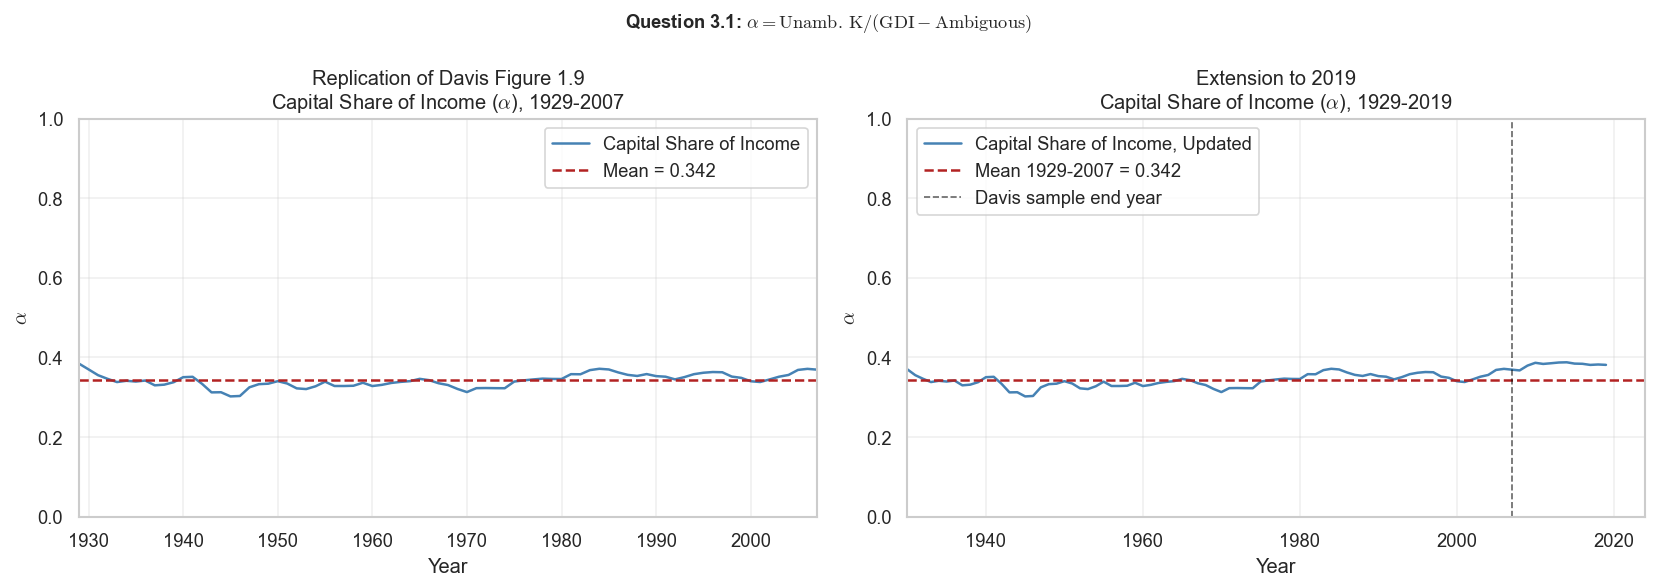

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot is replicating Davis's plot.
ax1 = axes[0]
ax1.plot(
    s07.index,
    s07.values,
    color='steelblue',
    lw=1.5,
    label='Capital Share of Income')
ax1.axhline(
    s07.mean(),
    color='firebrick',
    lw=1.5,
    ls='--',
    label=f'Mean = {s07.mean():.3f}')
ax1.set_xlim(1929, 2007)
ax1.set_ylim(0, 1)
ax1.set_xlabel('Year')
ax1.set_ylabel(r'$\alpha$')
ax1.set_title(
    "Replication of Davis Figure 1.9\n"
    r"Capital Share of Income ($\alpha$), 1929-2007"
)
ax1.legend()
ax1.grid(True, alpha=0.3)

# On the right side plot, the updated data up to 2019.
ax2 = axes[1]
ax2.plot(
    alpha_p3.index,
    alpha_p3.values,
    color='steelblue',
    lw=1.5,
    label='Capital Share of Income, Updated'
)
ax2.axhline(
    s07.mean(),
    color='firebrick',
    lw=1.5,
    ls='--',
    label=f'Mean 1929-2007 = {s07.mean():.3f}'
)
# Let's put a dashed vertical line to show where Davis's dataset
# had its end date.
ax2.axvline(
    2007,
    color='black',
    lw=1.0,
    ls='--',
    alpha=0.6,
    label='Davis sample end year')
ax2.set_xlim(1930, 2024)
ax2.set_ylim(0, 1)
ax2.set_xlabel('Year')
ax2.set_ylabel(r'$\alpha$')
ax2.set_title(
    "Extension to 2019\n"
    r"Capital Share of Income ($\alpha$), 1929-2019"
)
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle(
    r'Question 3.1: $\alpha = \mathrm{Unamb.\,K} / (\mathrm{GDI} - \mathrm{Ambiguous})$',    
    fontsize=11, fontweight='bold'
)
fig.tight_layout()
plt.show()


#### Alpha has increased in the years following 2007, as we see a noticably higher capital share in the right side plot here.


# Problem 4.0 -The Optimal Growth Model in the two period case.

Two period case $\implies T = 0, 1$

**Object function:**:

$$\max_{\{c_0,c_1,k_1,k_2\}\geq 0}\; u(c_0)+\beta\,u(c_1)$$

**Contraints:** $$\qquad c_t + k_{t+1} \leq f(k_t),\quad t=0,1$$

where<br>$f(k)=Ak^\alpha+(1-\delta)k$,<br>$u(c_t)=c_t^{1-\sigma}/(1-\sigma)$.


## Question 4.1 - Lagrangian

Apply the Lagrange multiplier, $\lambda_t\geq 0$, to each term and $\mu\geq 0$ to the non-negativity constraint $k_2\geq 0$:

$$\mathcal{L} = u(c_0) + \beta\,u(c_1)
+ \lambda_0\bigl[f(k_0)-c_0-k_1\bigr]
+ \lambda_1\bigl[f(k_1)-c_1-k_2\bigr]
+ \mu\,k_2$$

Two periods gives us the set of choice variables: $\{c_0,\,c_1,\,k_1,\,k_2\}$. Thus we have **4 variables, 4 first-order conditions**.


## Question 4.2 - Full system of equations

**4 first-order conditions** (from Q4.1):

$$\frac{\partial\mathcal{L}}{\partial c_0} = c_0^{-\sigma} - \lambda_0 = 0 \tag{1}$$

$$\frac{\partial\mathcal{L}}{\partial c_1} = \beta\,c_1^{-\sigma} - \lambda_1 = 0 \tag{2}$$

$$\frac{\partial\mathcal{L}}{\partial k_1} = -\lambda_0 + \lambda_1\,f'(k_1) = 0, \quad
f'(k_1) = \alpha A k_1^{\alpha-1}+(1-\delta) \tag{3}$$

$$\frac{\partial\mathcal{L}}{\partial k_2} = -\lambda_1 + \mu = 0\;\text{(KKT)}:\quad
\mu=\lambda_1>0 \;\text{ and }\; \mu k_2=0
\;\Rightarrow\; k_2=0 \tag{4}$$

**2 resource constraints:**

$$c_0 = f(k_0)-k_1 \tag{5}$$

$$c_1 = f(k_1), k_2=0 \tag{6}$$


**System:** 6 equations and 6 unknowns $\{c_0,c_1,k_1,k_2,\lambda_0,\lambda_1\}$.

## Question 4.3 - Verify the Euler condition at $t=0$.

In [138]:
# Question 4.3 - Use SymPy to verify the Euler condition at period t = 0.

beta_s, sigma_s, A_s, al_s, de_s = sp.symbols(
    r'\beta \sigma A \alpha \delta', positive=True)
c0_s, c1_s, k1_s = sp.symbols('c_0 c_1 k_1', positive=True)

# Derivatives from FOCs (1), (2), and (3).
lam0  = sp.diff(c0_s**(1-sigma_s)/(1-sigma_s), c0_s)
lam1  = sp.diff(c1_s**(1-sigma_s)/(1-sigma_s), c1_s) / beta_s
fp_k1 = sp.diff(A_s*k1_s**al_s + (1-de_s)*k1_s, k1_s)

# FOC (3) is given by lambda_0 = lambda_1 * f'(k1), so
# plug in (1) and (2).
euler = sp.Eq(lam0, beta_s * lam1 * fp_k1)
euler_simplified = sp.Eq(
    (c1_s/c0_s)**sigma_s,
    sp.simplify(beta_s * fp_k1)
)

display(Math(r'\text{Substituting (1) and (2) into (3):}'))
display(Math(sp.latex(euler)))
display(Math(r'\Longleftrightarrow'))
display(Math(sp.latex(euler_simplified)))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

####
This is an Euler condition because it is a first-order difference equation relating optimal choices at a given time period. Economically, it states that at the optimum value the household is indifferent between consuming one unit today and saving it.